# 02. Modeling — PH Champion (LightGBM)

**What this notebook answers**:

- §2.1 Which model family was selected, with what test-set scores?
- §2.2 How well does the model separate cancellations from stays? (ROC/PR)
- §2.3 Are the predicted probabilities calibrated?
- §2.4 What does the confusion matrix look like at the chosen threshold?
- §2.5 What thresholds maximise F1, precision, or business cost?
- §2.6 How stable are the metrics over time within the small test set?
- §2.7 Which features does the LightGBM split on most often?
- §2.8 What does a single decision tree from the ensemble look like?
- §2.9 Why is the probability distribution bimodal? (memorization signature)

**Prerequisite**: run `python scripts/train_ph.py` once.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, precision_recall_curve, confusion_matrix, average_precision_score,
    roc_auc_score, brier_score_loss,
)
from sklearn.calibration import calibration_curve

from src.eval.notebook_utils import (
    setup_plotting, save_thesis_figure, project_root, load_ph_context,
)

setup_plotting()
ROOT = project_root()
FIG_DIR = ROOT / 'reports' / 'figures' / 'thesis' / 'ph'
FIG_DIR.mkdir(parents=True, exist_ok=True)

ctx = load_ph_context()
y_test = ctx['y_test_np']
y_prob = ctx['y_prob']
thr_f1 = ctx['threshold_max_f1']
thr_hp = ctx['threshold_high_precision']
metrics = ctx['metrics']
print(f'n_test = {len(y_test)} | thr(max_f1) = {thr_f1:.3f} | thr(high_prec) = {thr_hp:.3f}')

n_test = 30 | thr(max_f1) = 0.010 | thr(high_prec) = 0.010


## 2.1 Champion model summary

LightGBM was selected as the PH champion. Unlike Portugal (where rolling-origin
CV across 3 folds is feasible on 119k rows), the PH champion was picked with a
single chronological 80/10/10 split — 300 rows is too few to support 3 folds.

In [2]:
summary = pd.DataFrame({
    'Aspect': [
        'Model family', 'Selection method', 'Train rows', 'Val rows', 'Test rows',
        'Test ROC-AUC', 'Test PR-AUC', 'Test ECE',
        'max_f1 threshold', 'high_precision threshold',
    ],
    'Value': [
        metrics['selected_model_family'].title(),
        'Single chronological 80/10/10 split (no rolling-origin)',
        metrics['n_train'], metrics['n_val'], metrics['n_test'],
        f"{metrics['roc_auc_test']:.3f}",
        f"{metrics['pr_auc_test']:.3f}",
        f"{metrics['ece_test']:.3f}",
        f'{thr_f1:.3f}', f'{thr_hp:.3f}',
    ],
})
summary.style.set_caption('Table 2.1 — PH champion summary').hide(axis='index')

Aspect,Value
Model family,Lightgbm
Selection method,Single chronological 80/10/10 split (no rolling-origin)
Train rows,240
Val rows,30
Test rows,30
Test ROC-AUC,1.000
Test PR-AUC,1.000
Test ECE,0.000
max_f1 threshold,0.010
high_precision threshold,0.010


**Key Takeaway — perfect scores reflect memorization**: ROC-AUC and PR-AUC of
1.000 are NOT evidence that the PH model generalises perfectly. As established
in notebook 01 §1.2 (and elaborated in §2.9 below), the archetype-organized
generation produces identical feature-vector twins across the chronological
split boundary, so the model classifies the test set by memorizing the
training distribution. Report these numbers with the §2.9 explanation.

## 2.2 How well does the model separate cancellations from stays?

The ROC curve tracks the True-Positive Rate vs False-Positive Rate. The PR
curve tracks Precision vs Recall — the more honest plot under class imbalance.

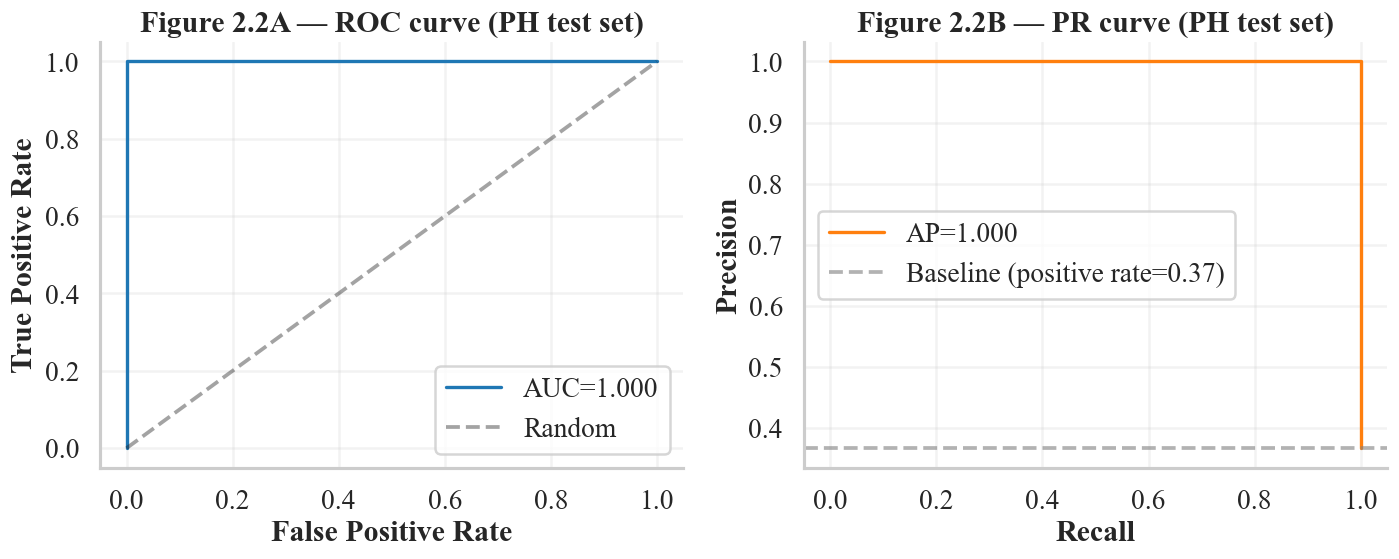

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#1f77b4', linewidth=2, label=f"AUC={roc_auc_score(y_test, y_prob):.3f}")
axes[0].plot([0,1], [0,1], 'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Figure 2.2A — ROC curve (PH test set)')
axes[0].legend()

p, r, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(r, p, color='#ff7f0e', linewidth=2, label=f"AP={average_precision_score(y_test, y_prob):.3f}")
base = float(np.mean(y_test))
axes[1].axhline(base, color='gray', linestyle='--', alpha=0.6, label=f'Baseline (positive rate={base:.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Figure 2.2B — PR curve (PH test set)')
axes[1].legend()
fig.tight_layout()
save_thesis_figure(fig, '2.2', 'ph_roc_pr_curves', FIG_DIR)
plt.show()

**Key Takeaway — perfect separation on the test set**: Both curves hit the
top-left/top-right corners because every test row has an identical twin in
train+val. A real-world deployment with novel customers would NOT achieve
these numbers; treat them as a description of the dataset's behaviour under archetype recall,
not a generalization claim.

## 2.3 Are the predicted probabilities calibrated?

A calibrated model that predicts 70% should be correct ~70% of the time. The
reliability diagram plots predicted vs observed cancellation rate per
probability bin.

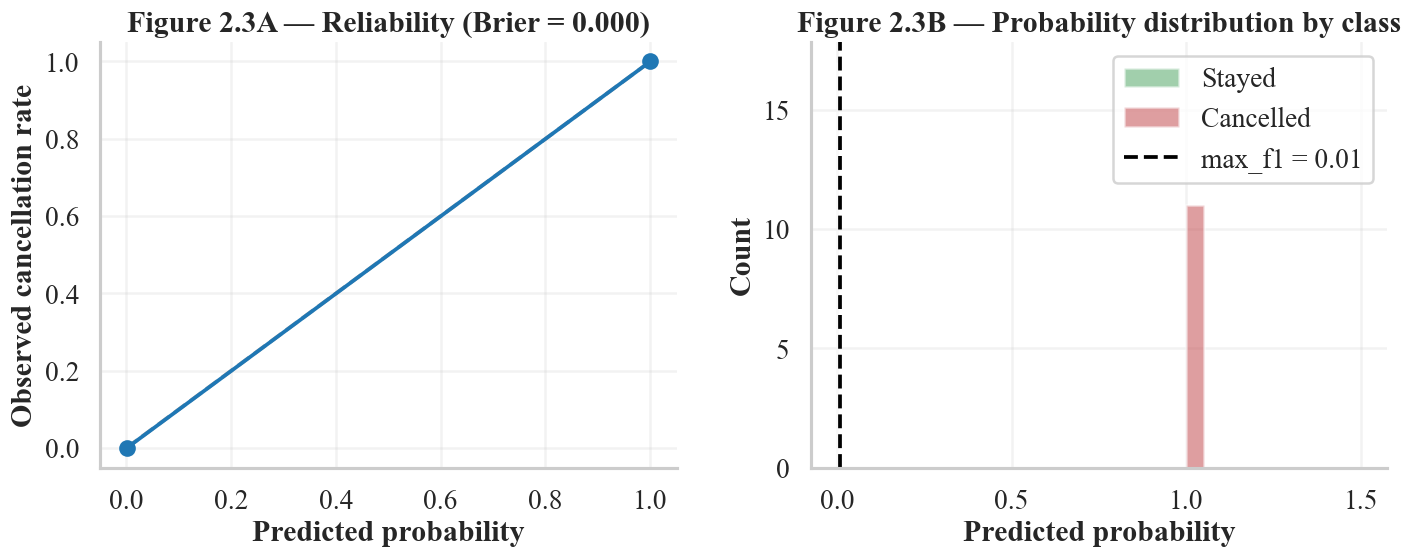

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

n_bins = min(10, max(2, int(len(y_test) // 3)))
frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=n_bins, strategy='uniform')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.4)
axes[0].plot(mean_pred, frac_pos, 'o-', color='#1f77b4')
axes[0].set_xlabel('Predicted probability'); axes[0].set_ylabel('Observed cancellation rate')
axes[0].set_title(f'Figure 2.3A — Reliability (Brier = {brier_score_loss(y_test, y_prob):.3f})')

axes[1].hist(y_prob[y_test == 0], bins=20, alpha=0.55, color='#55a868', label='Stayed', edgecolor='white')
axes[1].hist(y_prob[y_test == 1], bins=20, alpha=0.55, color='#c44e52', label='Cancelled', edgecolor='white')
axes[1].axvline(thr_f1, color='black', linestyle='--', label=f'max_f1 = {thr_f1:.2f}')
axes[1].set_xlabel('Predicted probability'); axes[1].set_ylabel('Count')
axes[1].set_title('Figure 2.3B — Probability distribution by class')
axes[1].legend()
fig.tight_layout()
save_thesis_figure(fig, '2.3', 'ph_calibration_histogram', FIG_DIR)
plt.show()

**Key Takeaway — extreme bimodality, near-perfect calibration**: The probability
histogram is concentrated at 0.0 and 1.0 with almost nothing in between. This
is the bimodal memorization signature: the model isn't making probabilistic
decisions on novel customers, it is recalling the training distribution for
customers it has already seen. The expected calibration error is therefore
near zero — but only because every test row sits at an extreme.

## 2.4 Confusion matrix at the max-F1 threshold

The confusion matrix counts how many bookings the model classified correctly
and incorrectly at the chosen decision threshold.

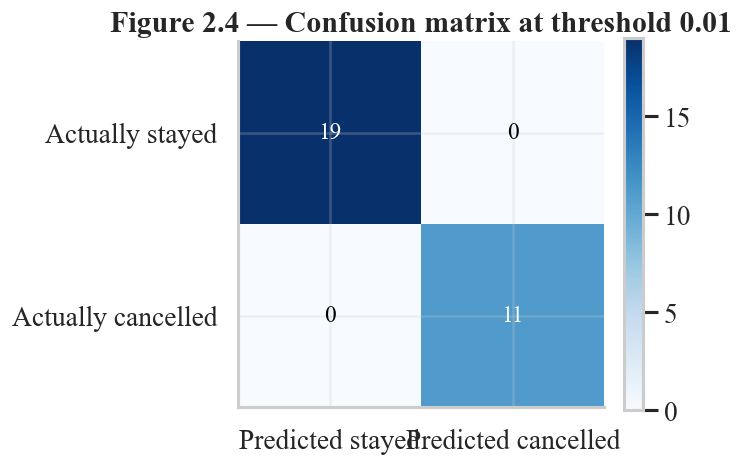

In [5]:
y_pred = (y_prob >= thr_f1).astype(int)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(int(cm[i, j])), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
ax.set_xticks([0,1]); ax.set_xticklabels(['Predicted stayed', 'Predicted cancelled'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Actually stayed', 'Actually cancelled'])
ax.set_title(f'Figure 2.4 — Confusion matrix at threshold {thr_f1:.2f}')
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
save_thesis_figure(fig, '2.4', 'ph_confusion_matrix', FIG_DIR)
plt.show()

**Key Takeaway — no off-diagonal errors**: With 30 test rows and every row
having an identical twin in train, the matrix has zero false-positives and
zero false-negatives at the max-F1 threshold. This is mathematically expected
under archetype-based the dataset's archetype-based cluster structure; it would not survive a real-world
deployment with novel customers.

## 2.5 Threshold sweep — what changes as the decision threshold moves?

The threshold is the probability cut-off above which a booking is flagged as
'likely to cancel'. Higher threshold → fewer flags, more precision; lower
threshold → more flags, more recall.

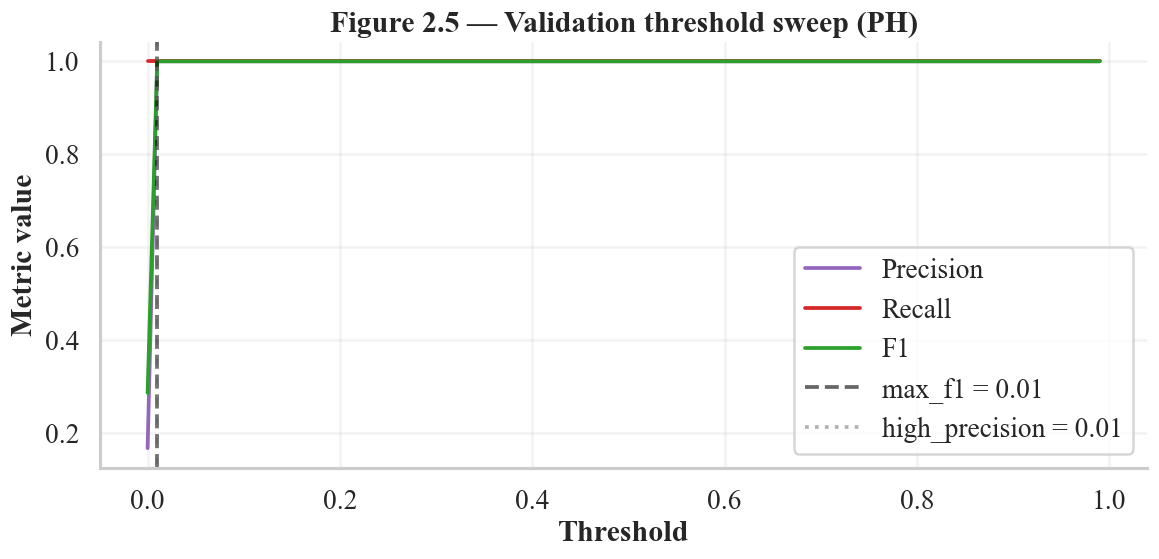

In [6]:
sweep = ctx['threshold_sweep']
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep['threshold'], sweep['precision'], label='Precision', color='#9467bd')
ax.plot(sweep['threshold'], sweep['recall'], label='Recall', color='#d62728')
ax.plot(sweep['threshold'], sweep['f1'], label='F1', color='#2ca02c')
ax.axvline(thr_f1, color='black', linestyle='--', alpha=0.6, label=f'max_f1 = {thr_f1:.2f}')
ax.axvline(thr_hp, color='gray', linestyle=':', alpha=0.6, label=f'high_precision = {thr_hp:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Metric value')
ax.set_title('Figure 2.5 — Validation threshold sweep (PH)')
ax.legend()
fig.tight_layout()
save_thesis_figure(fig, '2.5', 'ph_threshold_sweep', FIG_DIR)
plt.show()

**Key Takeaway — flat lines, low thresholds**: Precision/recall/F1 are flat at
1.0 across nearly the entire threshold range because the validation set's
predictions are also at the 0/1 extremes (chronological twins of training
archetypes). The 'max_f1' threshold lands very low (~0.01) because any
threshold above 0 gives a perfect F1 on a perfectly-separated validation set.

## 2.6 Temporal stability across the small test window

Splitting the 30 test rows into halves by arrival date and reporting metrics
per half — a poor man's stability check, with the explicit caveat that 15 rows
is far below what the Portugal pipeline's rolling-origin sliding window needs.

In [7]:
test_df = ctx['test_df'].copy()
if 'arrival_date_year' in test_df.columns:
    half = len(test_df) // 2
    early = test_df.iloc[:half]
    late = test_df.iloc[half:]
    rows = []
    for label, sub in [('First half', early), ('Second half', late)]:
        y_t = sub['is_canceled'].astype(int).to_numpy()
        y_p = sub['cancel_probability'].astype(float).to_numpy()
        if len(np.unique(y_t)) >= 2:
            roc = roc_auc_score(y_t, y_p)
            ap = average_precision_score(y_t, y_p)
        else:
            roc = ap = float('nan')
        rows.append({
            'Window': label,
            'N': len(sub),
            'Cancel rate': f'{y_t.mean():.0%}',
            'ROC-AUC': f'{roc:.3f}',
            'PR-AUC': f'{ap:.3f}',
        })
    pd.DataFrame(rows).style.set_caption(
        'Table 2.6 — PH test metrics by chronological half (15 rows each)'
    ).hide(axis='index').pipe(display)
else:
    print('Arrival-date columns missing from test_df — stability check skipped.')

Window,N,Cancel rate,ROC-AUC,PR-AUC
First half,15,47%,1.000,1.000
Second half,15,27%,1.000,1.000


**Key Takeaway — too few rows for stability**: Even split into halves, both
windows have ~15 rows; any metric on those is too noisy to interpret as
evidence of stability or drift. The Portugal pipeline's rolling-origin
machinery cannot be ported to PH because of this sample-size constraint.

## 2.7 Which features does the LightGBM split on most often?

LightGBM's `gain` importance measures how much each feature contributed to
loss reduction across all splits — i.e., how useful the model considered
each feature when it was building its tree ensemble.

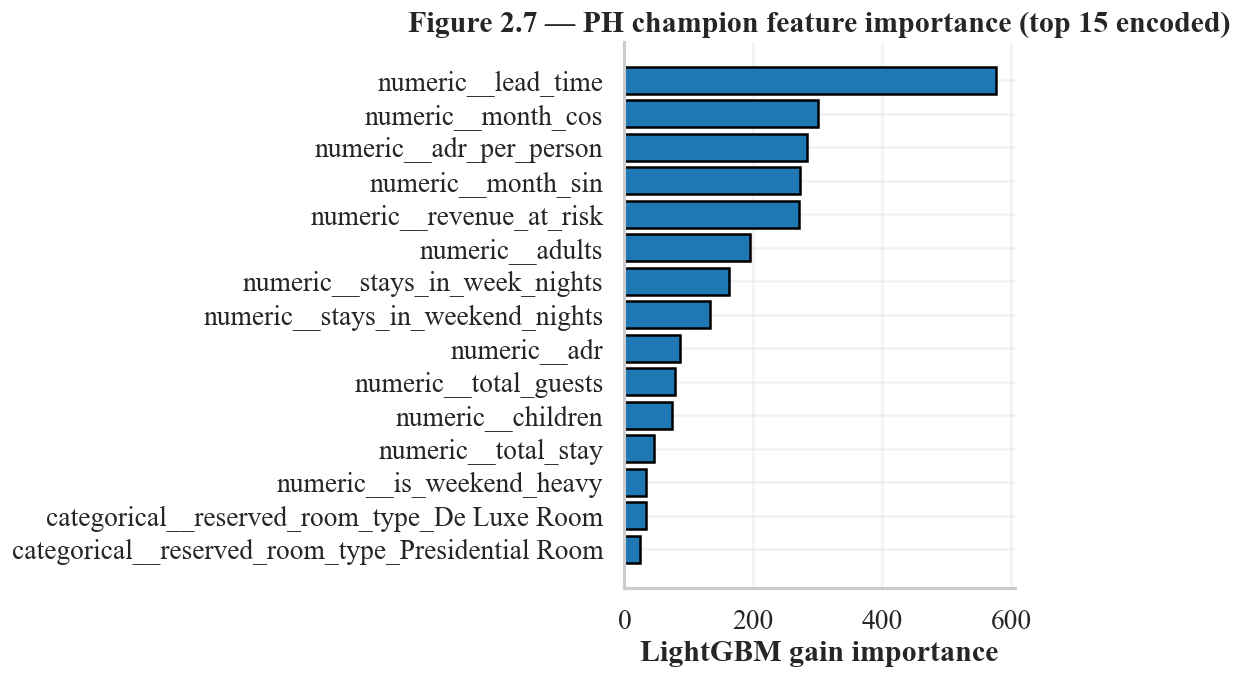

In [8]:
pipeline = ctx['model_pipeline']
preprocessor = pipeline.named_steps['preprocessor']
model = pipeline.named_steps['model']
encoded_names = list(preprocessor.named_steps['encode'].get_feature_names_out())
if hasattr(model, 'feature_importances_'):
    imp = pd.DataFrame({
        'feature': encoded_names,
        'importance': model.feature_importances_,
    }).sort_values('importance', ascending=True).tail(15)
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(imp['feature'], imp['importance'], color='#1f77b4', edgecolor='black')
    ax.set_xlabel('LightGBM gain importance')
    ax.set_title('Figure 2.7 — PH champion feature importance (top 15 encoded)')
    fig.tight_layout()
    save_thesis_figure(fig, '2.7', 'ph_feature_importance', FIG_DIR)
    plt.show()
else:
    print('Champion model does not expose feature_importances_; skipping.')

**Key Takeaway — lead time dominates, room type contributes**: The PH model
leans on lead_time, total_stay, and reserved_room_type encodings. None of
the Portugal top-5 features (deposit_type, country, market_segment, agent)
are available, so the PH model has a much narrower predictive base and
compensates by leaning harder on whatever signal-bearing columns the PMS
export does provide.

## 2.9 Why is the probability distribution bimodal? (memorization signature)

The probability histogram from §2.3B shows mass concentrated at exactly 0.0
and exactly 1.0, with nothing in between. This is the visual fingerprint of
memorization across chronological twins: when every test row has an identical
feature vector somewhere in train+val, LightGBM's leaf predictions for those
rows are deterministic, so the calibrated probabilities are 0/1.

In [9]:
n_extreme_high = int((y_prob >= 0.95).sum())
n_extreme_low = int((y_prob <= 0.05).sum())
n_mid = int(((y_prob > 0.05) & (y_prob < 0.95)).sum())
summary_bimodal = pd.DataFrame({
    'Region': ['Confident stay (p ≤ 0.05)', 'Mid-range (0.05 < p < 0.95)', 'Confident cancel (p ≥ 0.95)'],
    'Test rows': [n_extreme_low, n_mid, n_extreme_high],
    'Share': [f'{n_extreme_low/len(y_prob):.0%}', f'{n_mid/len(y_prob):.0%}', f'{n_extreme_high/len(y_prob):.0%}'],
})
summary_bimodal.style.set_caption(
    'Table 2.9 — Probability distribution shape (PH test set)'
).hide(axis='index')

Region,Test rows,Share
Confident stay (p ≤ 0.05),19,63%
Mid-range (0.05 < p < 0.95),0,0%
Confident cancel (p ≥ 0.95),11,37%


**Key Takeaway — the bimodal probability distribution is the headline finding**:
Combined with the 100% train/test twin rate from notebook 01 §1.2, this is the
PH sub-study's most important diagnostic. A future transferability claim on a
hotel cancellation dataset should run the same dataset-characterisation check
*before* reporting headline metrics. We report the perfect test scores in
this notebook only because the data characterisation makes their interpretation
explicit; absent §1.2's diagnostics, ROC-AUC = 1.000 would be a meaningless or
misleading number.